# **Project 3: Linear Classification**
Taha Akhlaq & Kenneth Chan

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from numpy import linalg as LA

np.random.seed(388)

# Parameters
N = 100  # number of samples
Mu1 = np.array([1, 1])
Mu2 = np.array([-1, -1])
Sigma = np.eye(2) # Asumming 2-D data from Mu1 and Mu2, so going with np.eye(2), not np.eye(1)

data_1 = np.random.multivariate_normal(Mu1, Sigma, N) # cluster 1 positive
data_2 = np.random.multivariate_normal(Mu2, Sigma, N) # cluster 2 negative

X = np.vstack([data_1, data_2])
Y = np.hstack([np.ones(N), np.zeros(N)])

X_with_w0 = np.hstack([np.ones((2 * N, 1)), X])

In [ ]:
# Method 1: Gaussian Generative Model

phi = np.mean(Y)

# Class means
Mu1_hat = np.mean(X[Y == 1], axis=0)
Mu2_hat = np.mean(X[Y == 0], axis=0)

# Shared covariance
Sigma_hat = ((X[Y == 1] - Mu1_hat).T @ (X[Y == 1] - Mu1_hat) +
             (X[Y == 0] - Mu2_hat).T @ (X[Y == 0] - Mu2_hat)) / (2 * N)

# w^T *x + b = 0
Sigma_inv = LA.inv(Sigma_hat)
w = Sigma_inv @ (Mu1_hat - Mu2_hat)
b = (-1/2 * (Mu1_hat.T @ Sigma_inv @ Mu1_hat)) + (1/2*(Mu2_hat.T @ Sigma_inv @ Mu2_hat)) + np.log(phi/(1-phi))

score = (X @ w) + b
Y_predicted = (score >= 0).astype(int)
actual = 100 * np.mean(Y_predicted == Y)
print("Accuracy for Gauss: ", actual)

Accuracy for Gauss:  91.0


In [ ]:
# Method 2: Logistic Regression, IRLS algorithm

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def IRLS (X, Y, iterations = 25, tolerance = 1e-6):
    n, d = X.shape
    w = np.zeros(d)

    for i in range(iterations):
        p = sigmoid(X @ w)  # Predicted probabilities
        W = np.diag(p * (1 - p))  # Weight matrix
        z = X @ w + (Y - p) / (p * (1 - p + 1e-10))

        # Solve weighted least squares: (X^T W X) w_new = X^T W z
        w_new = LA.pinv(X.T @ W @ X) @ X.T @ W @ z

        if np.linalg.norm(w_new - w) < tolerance:
            break
        w = w_new

    return w


w2 = IRLS(X_with_w0, Y)
score2 = X_with_w0 @ w2
Y_predicted2 = (score2 >= 0).astype(int)
actual2 = 100 * np.mean(Y_predicted2 == Y)
print("Accuracy for IRLS: ", actual2)

Accuracy for IRLS:  95.0


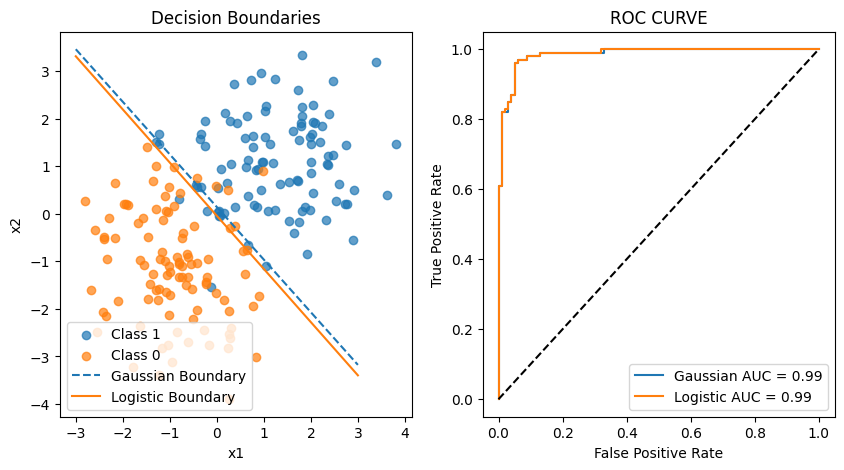

In [ ]:
# ROC curve
FPR, TPR, _ = roc_curve(Y, score)
AUC = auc(FPR, TPR)
FPR2, TPR2, _ = roc_curve(Y, score2)
AUC2 = auc(FPR2, TPR2)

x_vals = np.linspace(-3, 3, 100)
plt.figure(figsize=(10, 5))

# Scatterplot!
plt.subplot(1, 2, 1)
plt.scatter(data_1[:, 0], data_1[:, 1], label="Class 1", alpha=0.7)
plt.scatter(data_2[:, 0], data_2[:, 1], label="Class 0", alpha=0.7)

# Decision boundary for Gauss
a, b_gauss = w
c_gauss = b
y_vals_gen = -(a * x_vals + c_gauss) / b_gauss
plt.plot(x_vals, y_vals_gen, label='Gaussian Boundary', linestyle='--')

# Decision boundary for IRLS
a2, b2 = w2[1], w2[2]
c2 = w2[0]
y_vals_log = -(a2 * x_vals + c2) / b2
plt.plot(x_vals, y_vals_log, label='Logistic Boundary', linestyle='-')

plt.legend()
plt.title("Decision Boundaries")
plt.xlabel("x1")
plt.ylabel("x2");

plt.subplot(1, 2, 2)
plt.plot(FPR, TPR, label=f'Gaussian AUC = {AUC:.2f}')
plt.plot(FPR2, TPR2, label=f'Logistic AUC = {AUC2:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC CURVE")
plt.legend()
plt.show()

In [ ]:
# DATASET FROM UCI ML database
# Note, only using the first two features of that set
# Link to dataset: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import roc_curve, auc

np.random.seed(388)

# Load real-world dataset
dataset = load_breast_cancer()
X = dataset.data[:, :2]  # Use only first 2 features for 2D visualization
Y = dataset.target       # Binary: 0 = malignant, 1 = benign

# Add bias term for logistic regression
X_with_w0 = np.hstack([np.ones((X.shape[0], 1)), X])

# Method 1: Gaussian Generative Model

phi = np.mean(Y)
Mu1_hat = np.mean(X[Y == 1], axis=0)
Mu2_hat = np.mean(X[Y == 0], axis=0)

Sigma_hat = ((X[Y == 1] - Mu1_hat).T @ (X[Y == 1] - Mu1_hat) +
             (X[Y == 0] - Mu2_hat).T @ (X[Y == 0] - Mu2_hat)) / len(Y)

Sigma_inv = np.linalg.inv(Sigma_hat)
w = Sigma_inv @ (Mu1_hat - Mu2_hat)
b = (-1/2 * Mu1_hat.T @ Sigma_inv @ Mu1_hat) + (1/2 * Mu2_hat.T @ Sigma_inv @ Mu2_hat) + np.log(phi / (1 - phi))

score = X @ w + b
Y_predicted = (score >= 0).astype(int)
actual = 100 * np.mean(Y_predicted == Y)
print("Accuracy for Gauss: ", actual)

# Method 2: Logistic Regression with IRLS

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def IRLS(X, Y, iterations=25, tolerance=1e-6):
    n, d = X.shape
    w = np.zeros(d)

    for i in range(iterations):
        p = sigmoid(X @ w)  # Predicted probabilities
        W = np.diag(p * (1 - p))  # Weight matrix
        z = X @ w + (Y - p) / (p * (1 - p + 1e-10))

        # Solve weighted least squares: (X^T W X) w_new = X^T W z
        w_new = LA.pinv(X.T @ W @ X) @ X.T @ W @ z

        if np.linalg.norm(w_new - w) < tolerance:
            break
        w = w_new

    return w

w2 = IRLS(X_with_w0, Y)
score2 = X_with_w0 @ w2
Y_predicted2 = (score2 >= 0).astype(int)
actual2 = 100 * np.mean(Y_predicted2 == Y)
print("Accuracy for IRLS: ", actual2)

Accuracy for Gauss:  88.57644991212655
Accuracy for IRLS:  89.103690685413


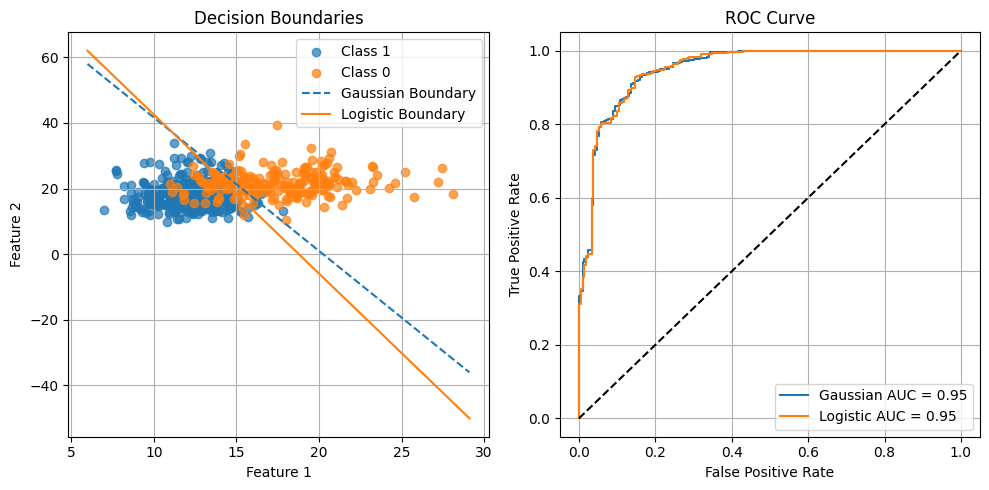

In [ ]:
# ROC curves
FPR, TPR, _ = roc_curve(Y, score)
AUC = auc(FPR, TPR)
FPR2, TPR2, _ = roc_curve(Y, score2)
AUC2 = auc(FPR2, TPR2)

# Plotting
x_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)

plt.figure(figsize=(10, 5))

#SCATTERING
plt.subplot(1, 2, 1)
plt.scatter(X[Y == 1][:, 0], X[Y == 1][:, 1], label="Class 1", alpha=0.7)
plt.scatter(X[Y == 0][:, 0], X[Y == 0][:, 1], label="Class 0", alpha=0.7)

# Gaussian decision boundary
a, b_gauss = w
c_gauss = b
y_vals_gen = -(a * x_vals + c_gauss) / b_gauss
plt.plot(x_vals, y_vals_gen, label='Gaussian Boundary', linestyle='--')

# IRLS decision boundary
a2, b2 = w2[1], w2[2]
c2 = w2[0]
y_vals_log = -(a2 * x_vals + c2) / b2
plt.plot(x_vals, y_vals_log, label='Logistic Boundary', linestyle='-')

plt.title("Decision Boundaries")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid()

# ROC curve
plt.subplot(1, 2, 2)
plt.plot(FPR, TPR, label=f'Gaussian AUC = {AUC:.2f}')
plt.plot(FPR2, TPR2, label=f'Logistic AUC = {AUC2:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()